# Étape 2 — Prétraitement et Exploration des Données
### Dataset : all_youtube_comments.csv

## Cellule 1 — Imports

In [12]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
import emoji

print('✅ Imports OK')

✅ Imports OK


## Cellule 2 — Charger les données

In [13]:
df = pd.read_csv('../data/raw/all_domains_comments.csv', encoding='utf-8-sig')

print(f'Nombre de textes : {len(df)}')
print(f'\nColonnes : {df.columns.tolist()}')
print(f'\nRépartition par catégorie :')
print(df['category'].value_counts())

Nombre de textes : 61297

Colonnes : ['id', 'text', 'source_platform', 'source_type', 'source_account', 'category', 'date', 'label']

Répartition par catégorie :
category
Politics/Société     18815
Business/Économie    13195
Sports/Fitness       12316
Medical/Santé         8157
Food/Cuisine          4606
Religion              4208
Name: count, dtype: int64


## Cellule 3 — Voir des exemples bruts

In [14]:
pd.set_option('display.max_colwidth', 200)
df[['text', 'category', 'source_type']].sample(10)

,text,category,source_type
59116,سير تشوف لي يحويك ازبي كتعرف القلاوي لي كتعرف النقد من أجل النقد,Sports/Fitness,comment
47553,بنادم غادي يتزوج ببنادم غادي يعيشوا كبنادم ضحكتني اعمي ياسين راه كنستاافدوا منك لكثير شكرا بزاف 🙏🤍,Religion,comment
39668,هنية غير حافظة وما فاهماش فوق ما هضر يتكلم على عدم وضع البيض في سلة واحدة وفين بغيتيه يعملوه في قاعك,Politics/Société,comment
19587,شخصيا عانيت فالمستشفيات ديال دولة ولولا الكلينيكات لو نا كنت حي و مرضت نفسيا بسبب طبيبة عطاتني celéstène لمدة اكثر من 3 أشهر مما أدى لأنني يكون عندي مرض اديسون و هادشي كامل فسنة الباكالوريا و نزيد...,Medical/Santé,comment
5998,بغينا الجديد الله يحافضك,Business/Économie,comment
33197,♥️♥️🔥🔥🔥🔥🔥,Politics/Société,comment
49128,Ukraine fiha lharb ol9wada ojabo 12 medalia rotba 22 3alamian . 3ilma an lflos li sarfo 3lihom 9al man dakchi li srafna 3la diawlna 😮😮,Sports/Fitness,comment
40556,هناوي السفيه اهرب راه جاي اسعد الشرعي,Politics/Société,comment
6542,سخفتيني أصاحبي😥😥 مالك طاير فالهضرة 😁😁😁 تاغير بشوية عليا أوااه 😬 ..ومع ختك ثقيلة فالفهم والاستيعاب يلاه رديت البال للتعويم بديت كانقلب شنو هو بعدا 🙄😉😉😉\nشكرا أخويا بزااف على الشرح المبسط حيث كل واح...,Business/Économie,comment
25503,Merci pour cette vidéo \nKhedma wa3ra \nFin partie 2 de najib?,Medical/Santé,comment


## Cellule 4 — Détecter les problèmes

In [15]:
vides = df['text'].isna().sum()
print(f'Textes vides : {vides}')

courts = df[df['text'].str.split().str.len() <= 2]
print(f'Textes <= 2 mots : {len(courts)}')
print('\nExemples :')
print(courts['text'].head(10).tolist())

doublons = df.duplicated(subset=['text']).sum()
print(f'\nDoublons : {doublons}')

Textes vides : 1
Textes <= 2 mots : 8207

Exemples :
['😎😎😎😎😎', 'سطارطير', '🌍', '😀', '😊😊😊😊', '😎😎😎😎', '😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎', '😎', '❤😢', '❤']

Doublons : 0


## Cellule 5 — Exemples de spam

In [16]:
# Cellule 5 — Exemples de spam
def has_repetition(text):
    if not isinstance(text, str):
        return False
    for i in range(len(text) - 4):
        if text[i] == text[i+1] == text[i+2] == text[i+3] == text[i+4]:
            return True
    return False

spam = df[df['text'].apply(has_repetition)]
print(f'Textes avec répétitions abusives : {len(spam)}')
print('\nExemples :')
print(spam['text'].head(10).tolist())

Textes avec répétitions abusives : 6026

Exemples :
['😎😎😎😎😎', '😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎😎', '😎😎😎😎😎😎', '😎😎😎😎😎bravo', 'MERCI\n😎😎😎😎😎😎😎😎😎😎', 'راه ديرين هادشي باش الحكومة لغتجي العام جاي  تلقى الصندوق خاوي اودي لعفووووو', '😊😊😊😊😊', 'tbarkellah 3liik khoya Swinga dakchi wa3errr.....', "riche en information , merci l'équipe pour ses efforts , 👏👏👏👏👏 bonne continuation", 'اش هاد المهزلة و اش هاد الحكرة يا ربي تسهل علينا نخويو هاد البلاد على الاقل الى خلصنا ضرائب كتبان على الشعب فالتعليم و الصحة و التأمين.....']


## Cellule 6 — Fonction de nettoyage

In [17]:
import re
import emoji

GENERIC_COMMENTS = {
    'bravo', 'top', 'nice', 'good', 'merci', 'شكرا', 'شكراً',
    'tbarkallah', 'machallah', 'ماشاء', 'الله'
}

CTA_PATTERNS = [
    r'\bsubscribe\b', r'\bsub\b', r'\babonne\b', r'\babonner\b',
    r'اشترك', r'لايك', r'بارتاج', r'partage', r'comment', r'كومنطي'
]

MSA_HINTS = {
    'يجب', 'جميع', 'الأحزاب', 'السياسية', 'المتظاهرين', 'السلميين',
    'رجال', 'الأمن', 'السلطات', 'استقالة', 'الصحافة', 'المستوى'
}

DARIJA_HINTS = {
    'واش', 'علاش', 'حيت', 'حيتاش', 'ديال', 'عندي', 'عندو', 'عندها',
    'بزاف', 'هاد', 'هاذ', 'راه', 'ماشي', 'كاين', 'كين', 'مزيان',
    'دابا', 'غادي', 'عافاك', 'حنا', 'نتا', 'نتي'
}

def basic_clean(text):
    if not isinstance(text, str):
        return None

    text = text.strip()
    if not text:
        return None

    # URLs / mentions / hashtags
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)

    # Emojis
    text = emoji.replace_emoji(text, replace=' ')

    # Garder arabe + latin + chiffres + ponctuation utile
    text = re.sub(r"[^\u0600-\u06FF\u0750-\u077Fa-zA-Z0-9\s،,.!?;:%'\"()-]", ' ', text)

    # Réduire répétitions
    text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)

    # Espaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text if text else None

def is_only_numbers_or_punct(text):
    return bool(re.fullmatch(r'[\W\d_ ]+', text))

def token_count(text):
    return len(text.split())

def is_generic_comment(text):
    t = text.lower().strip()
    words = t.split()
    if len(words) <= 2 and any(w in GENERIC_COMMENTS for w in words):
        return True
    return False

def has_pattern(text, patterns):
    return any(re.search(p, text, flags=re.IGNORECASE) for p in patterns)

def score_msa_vs_darija(text):
    words = set(text.split())
    msa_score = sum(1 for w in words if w in MSA_HINTS)
    darija_score = sum(1 for w in words if w in DARIJA_HINTS)
    return msa_score, darija_score

def is_msa_dominant(text):
    msa, darija = score_msa_vs_darija(text)
    return msa >= 2 and darija == 0

def is_fr_en_dominant(text):
    if re.search(r'[\u0600-\u06FF]', text):
        return False

    words = text.lower().split()
    if len(words) < 3:
        return False

    fr_en_markers = {
        'je','tu','il','elle','nous','vous','the','is','are','with','for',
        'merci','bonjour','good','nice','video','great','love','thanks'
    }
    count = sum(1 for w in words if w in fr_en_markers)
    return count / max(len(words), 1) >= 0.4

def clean_text(text):
    text = basic_clean(text)
    if text is None:
        return None

    if is_only_numbers_or_punct(text):
        return None

    if has_pattern(text, CTA_PATTERNS):
        return None

    return text

## Cellule 7 — Appliquer le nettoyage de base

In [18]:
avant = len(df)
print(f'Avant nettoyage : {avant}')

# Nettoyage léger
df['text_clean'] = df['text'].apply(clean_text)

# Supprimer vides
df = df.dropna(subset=['text_clean'])

# Supprimer doublons sur texte nettoyé
df = df.drop_duplicates(subset=['text_clean'])

print(f'Après nettoyage léger : {len(df)}')
print(f'Supprimés             : {avant - len(df)}')

Avant nettoyage : 61297
Après nettoyage léger : 55761
Supprimés             : 5536


## Cellule 8 — Vérifier avant/après nettoyage

In [19]:
pd.set_option('display.max_colwidth', 150)
df[['text', 'text_clean']].sample(15)

,text,text_clean
33734,كنت نتفرج فاش وصلتي وقلت الدولة القديمة كانت تكون من ومن ومدكرتيش بلي الدولة الاسلامية كانت تسير بالولاء ويتحول من الى حسب الشورى \nانسحبت من الفيديو,كنت نتفرج فاش وصلتي وقلت الدولة القديمة كانت تكون من ومن ومدكرتيش بلي الدولة الاسلامية كانت تسير بالولاء ويتحول من الى حسب الشورى انسحبت من الفيديو
51534,غي تخايل سكيتيوي شاد منتخب بهاد لعابة كاملين غادي عطي بحرين شي 8,غي تخايل سكيتيوي شاد منتخب بهاد لعابة كاملين غادي عطي بحرين شي 8
23912,اخيرا هههههه على سلامتك,اخيرا ههه على سلامتك
12825,دمت متوفقا في اصول المعلومة المفيدة,دمت متوفقا في اصول المعلومة المفيدة
29661,ابداع في شرح و طرح التاريخ مشكور عليه و لكن هنالك مغالطات كبيرة في فيديو من بينها ان دولة فاطيمة امتدت من على كل المغرب العربي حتى الفاس و كذلك ال...,ابداع في شرح و طرح التاريخ مشكور عليه و لكن هنالك مغالطات كبيرة في فيديو من بينها ان دولة فاطيمة امتدت من على كل المغرب العربي حتى الفاس و كذلك ال...
51180,Ahsan mo71lil,Ahsan mo71lil
568,شكرا على مجهودك الرائع,شكرا على مجهودك الرائع
37384,تستاحق وسام مستحق 🎖🇲🇦👏🏻,تستاحق وسام مستحق
55486,وخاص تلاربيط يخرج ويقول لنا علاش محسبس البيت ديال الرجاء والمعلقين خاصنا تجديد في الأصوات 🦅🦅🦅🦅💚,وخاص تلاربيط يخرج ويقول لنا علاش محسبس البيت ديال الرجاء والمعلقين خاصنا تجديد في الأصوات
1205,الموظف الأجير هو لي ضايع في نسبة الضريبة.\n راه بزاف و ظلم كبير. يسرقونه تحت إسم القانون خخخخ. الله ينعل كل مسؤول فاسد,الموظف الأجير هو لي ضايع في نسبة الضريبة. راه بزاف و ظلم كبير. يسرقونه تحت إسم القانون خخخ. الله ينعل كل مسؤول فاسد


## Cellule 9 — Filtrage avancé 

In [ ]:
# --- Ressources pour détection MSA / Darija / FR-EN ---
MSA_HINTS = {
    'يجب', 'ينبغي', 'يمكن', 'جميع', 'الأحزاب', 'السياسية', 'المواطنين',
    'المتظاهرين', 'السلميين', 'رجال', 'الأمن', 'السلطات', 'استقالة',
    'الصحافة', 'المستوى', 'الذي', 'التي', 'هذا', 'هذه', 'ذلك',
    'تلك', 'هناك', 'حيث', 'كما', 'لقد', 'تم', 'أثناء', 'منذ',
    'حول', 'ضمن', 'إلى', 'على', 'بعد', 'قبل', 'مع', 'بين'
}

DARIJA_HINTS = {
    'واش', 'علاش', 'حيت', 'حيتاش', 'ديال', 'د', 'عندي', 'عندو', 'عندها',
    'بزاف', 'هاد', 'هاذ', 'راه', 'ماشي', 'كاين', 'كين', 'مزيان',
    'دابا', 'غادي', 'عافاك', 'حنا', 'نتا', 'نتي', 'بصح', 'صح',
    'فين', 'كيفاش', 'عفاك', 'بلا', 'والو', 'حاجة', 'شحال'
}

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    return re.findall(r'[\u0600-\u06FFa-zA-Z0-9]+', text.lower())

def score_msa_vs_darija(text):
    words = tokenize_text(text)
    msa_score = sum(1 for w in words if w in MSA_HINTS)
    darija_score = sum(1 for w in words if w in DARIJA_HINTS)
    return msa_score, darija_score, len(words)

def is_msa_dominant(text):
    if not isinstance(text, str):
        return False

    words = tokenize_text(text)
    if len(words) < 3:
        return False

    msa_score, darija_score, total = score_msa_vs_darija(text)

    if msa_score >= 2 and darija_score == 0:
        return True

    msa_ratio = msa_score / max(total, 1)
    if msa_score >= 3 and msa_ratio >= 0.2 and darija_score == 0:
        return True

    return False

def is_fr_en_dominant(text):
    if not isinstance(text, str):
        return False

    # présence d'arabe => pas "purement" FR/EN
    if re.search(r'[\u0600-\u06FF]', text):
        return False

    words = tokenize_text(text)
    if len(words) < 3:
        return False

    darija_latin_markers = {
        'wach', '3lach', '7it', 'hit', 'bzf', 'bzaf', 'had', 'hada', 'hadi',
        'makayn', 'ma3ndich', 'machi', 'rah', 'safi', 'walou', 'daba',
        'ghadi', 'nta', 'nti', 'kifach', 'fin', 'mskin', 'meskin'
    }

    fr_en_markers = {
        'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
        'the', 'is', 'are', 'with', 'for', 'this', 'that', 'and',
        'merci', 'bonjour', 'salut', 'good', 'nice', 'great', 'video',
        'love', 'thanks', 'please', 'very', 'well', 'best', 'super'
    }

    fr_en_score = sum(1 for w in words if w in fr_en_markers)
    darija_latin_score = sum(1 for w in words if w in darija_latin_markers)

    if fr_en_score >= 2 and darija_latin_score == 0:
        return True

    if fr_en_score / max(len(words), 1) >= 0.4 and darija_latin_score == 0:
        return True

    return False


# --- Suppression des mots vulgaires + filtrage avancé ---
mots_interdits = [
    r'\b9awad\b', r'\b9lawi\b', r'\bzebi\b', r'\bzbi\b',
    r'\bt7wa\b', r'\bl7wa\b', r'\b9ahba\b', r'\b3ahra\b',
    r'\bmkhanez\b', r'\bmchayef\b',
    r'\bقود\b', r'\bزبي\b', r'\bقلاوي\b',
    r'\bلحوا\b', r'\bعاهرة\b', r'\bقحبة\b'
]

pattern_vulgaire = re.compile('|'.join(mots_interdits), re.IGNORECASE)
def contient_vulgaire(text):
    if not isinstance(text, str):
        return False
    return bool(pattern_vulgaire.search(text))

def est_informatif(text):
    if not isinstance(text, str):
        return False

    if token_count(text) < 2:
        return False

    if is_only_numbers_or_punct(text):
        return False

    if is_generic_comment(text):
        return False

    return True

avant_avance = len(df)
print(f'Avant filtrage avancé : {avant_avance}')

df['is_vulgar'] = df['text_clean'].apply(contient_vulgaire)
df['is_fr_en_dominant'] = df['text_clean'].apply(is_fr_en_dominant)
df['is_msa_dominant'] = df['text_clean'].apply(is_msa_dominant)
df['is_generic'] = df['text_clean'].apply(is_generic_comment)
df['is_informative'] = df['text_clean'].apply(est_informatif)

mask_vulgar = df['is_vulgar']
mask_fr_en = df['is_fr_en_dominant']
mask_msa = df['is_msa_dominant']
mask_bad = ~df['is_informative']

print(f'  Vulgaires       : {mask_vulgar.sum()}')
print(f'  FR/EN dominants : {mask_fr_en.sum()}')
print(f'  MSA dominants   : {mask_msa.sum()}')
print(f'  Génériques      : {df["is_generic"].sum()}')
print(f'  Non informatifs : {mask_bad.sum()}')

df_clean = df.loc[
    ~mask_vulgar &
    ~mask_fr_en &
    ~mask_msa &
    ~mask_bad
].copy()

print(f'\nAprès filtrage avancé : {len(df_clean)}')
print(f'Total supprimés       : {avant_avance - len(df_clean)}')

Avant filtrage avancé : 55761
  Vulgaires       : 42
  FR/EN dominants : 853
  MSA dominants   : 3582
  Génériques      : 356
  Non informatifs : 1976

Après filtrage avancé : 49310
Total supprimés       : 6451


## Cellule 10 — Vérifier ce qui a été supprimé

In [21]:
print('=== Vulgaires supprimés ===')
print(df[mask_vulgar]['text_clean'].head(5).tolist())

print('\n=== FR/EN supprimés ===')
print(df[mask_fr_en]['text_clean'].head(5).tolist())

print('\n=== MSA dominants supprimés ===')
print(df[mask_msa]['text_clean'].head(5).tolist())

print('\n=== Génériques supprimés ===')
print(df[df['is_generic']]['text_clean'].head(5).tolist())

print('\n=== Non informatifs supprimés ===')
print(df[mask_bad]['text_clean'].head(5).tolist())

=== Vulgaires supprimés ===
['38٪ ههه لحوا هدا جاع رؤوس الأموال غدي اهربو وشوف منين تجيب المداخيل', 'باختصار خمسة عشر طائرة التي ذهبت إلى لبنان كافية تخلص نصف الديون خصوصا والمخنث ديال ابن الحريري في ليلة واحدة حمراء مع عاهرة برازيلية ينفق 49مليار. حلل وناقش؟ خلاصة القول الدول العربية كلها فاسدة', 'بغيت نقولك اسي زبي شنو غادي يربح مواطن عادي من هاذ الهيلالة كلها ...واش كاين شي حقل نفط فالصحرا لغاذي يطيح الثمن دلمازوط ولا الغاز مهم كاين.. وغاذي نستافدو الريح كاملين ولي عارف شي عوينة يشرب معا راسو منها واراك لتطبال والتغياط منك وجبد...ههه راحنا ف 2025 والمغرب باقي 1939 .. اخر الكلام جميعا بكم الى جهنم وبيس المصير', 'هاد العنوان فيه استفزاز للمغاربة وخيانة زبي مكان لحكم داتي ولا زبي الاندماج او الإبادة', 'مروكي بيروكي ... حسب موقع قوقل عالمي صرح ان الشعب مغربي اكبر شعب كذاب وغير مؤتمن في عالم ...الادارسة والسعديبن والعلويين هم من سعودية والسعودية تعرف بهذا ...كيفاه اصبحوا مغاربة او مراكشيبن او فاسيين ...فهمونا ...برك ... او زيد ...الموحدين اسسها عبد مؤمن كومي تلمساني وسيطر على فاس وكل اول

## Cellule 11 — Vérifier ce qui reste

In [22]:
print('=== Exemples gardés ===')
print(df_clean['text_clean'].sample(15).tolist())

print(f'\nRépartition finale :')
print(df_clean['category'].value_counts())

=== Exemples gardés ===
['واوووشرشحونا اولاد الكلاب', 'تحية للعلم والمعرفة الغرب صراحة قوي جدا.. أين الإسلام وناس حبة السوداء اينكم', 'جزاكم الله خيرا على هذهيا نصائح المهيمة جدا', 'أنا كنتسنا المنتخب يلعب كأس إفريقيا و يلعب ضد السنغال و يخرج بشوهة هادا هو الحلم ديالي', 'تبارك الله عليكم ماشاء الله خدمة نقية ماخليتو لينا مانقولو برافو', 'أولا يحصل لي الشرف كمغربي نشوف قناة بحال هادي مغربية و مقادها ولد بلادي. نحن المغاربة يجب علينا مساندة القنواة الهادفة من أجل تنقية الويب المغربي من التفاهات. و نرجعو كيفما كنا مهيبيين بحال المنصور الذهبي.', 'برفو فديو مزاين او عرفنا حجا اخرى انك رجاوي ههه دقيقة 28h30', 'سبحان الخالق الذي ابدع في خلقه', 'ولمعرفة الحقيقة الواجب الرجوع الى الأطباء والباحثين المختصين وليس السياسيين الكاذبين', 'ترا واحد الاحساس ديال الفخر راه بزاف', 'صراح شرحتي مناعة بافضل شرح', 'thanks you', 'انا اشكر السي الهناوي على طريقة التحليل والاجوبة المقنعة', 'شاب الله يحفظك', 'تبارك الله عليك أختي باين بيني زوين أنا غادي نجرب المقادير ديالك شكرا لك']

Répartition finale :
categor

## Cellule 12 — Longueur moyenne par source

Longueur des textes par source :
             Moyenne  Min  Max  Médiane
source_type                            
comment         14.6    2  997      9.0


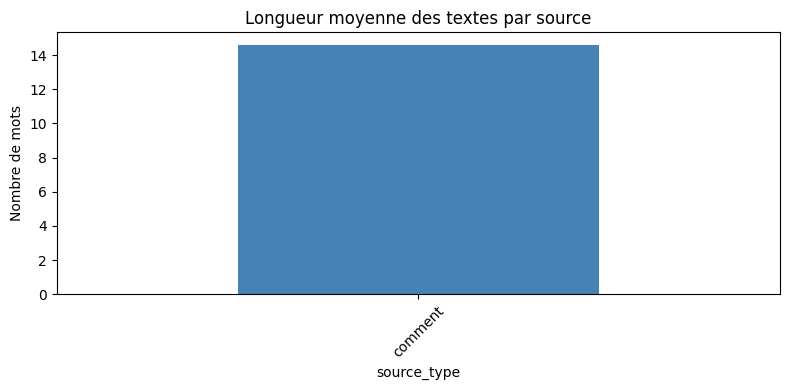

In [23]:
df_clean['nb_mots'] = df_clean['text_clean'].str.split().str.len()

longueur = df_clean.groupby('source_type')['nb_mots'].agg(['mean','min','max','median'])
longueur.columns = ['Moyenne', 'Min', 'Max', 'Médiane']
longueur = longueur.round(1)

print('Longueur des textes par source :')
print(longueur)

longueur['Moyenne'].plot(kind='bar', color='steelblue', figsize=(8,4))
plt.title('Longueur moyenne des textes par source')
plt.ylabel('Nombre de mots')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cellule 13 — Distribution arabe vs latin

Distribution arabe vs latin par catégorie :
                   pct_arabic  pct_latin
category                                
Business/Économie        73.6       26.4
Food/Cuisine             85.7       14.3
Medical/Santé            77.9       22.1
Politics/Société         83.1       16.9
Religion                 94.7        5.3
Sports/Fitness           72.8       27.2


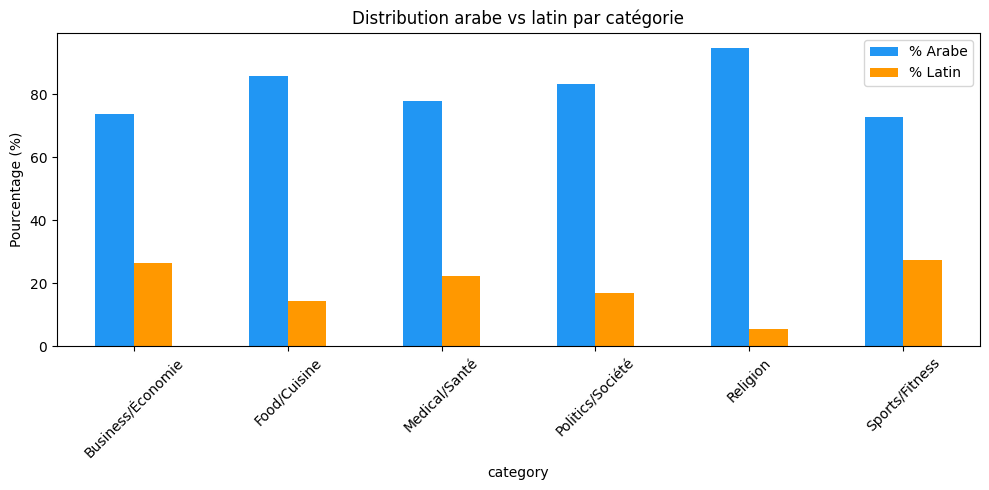

In [24]:
def detect_script(text):
    if not isinstance(text, str):
        return 0, 0
    arabic = len(re.findall(r'[\u0600-\u06FF]', text))
    latin  = len(re.findall(r'[a-zA-Z]', text))
    return arabic, latin

df_clean['arabic_chars'] = df_clean['text_clean'].apply(lambda x: detect_script(x)[0])
df_clean['latin_chars']  = df_clean['text_clean'].apply(lambda x: detect_script(x)[1])
df_clean['total_chars']  = df_clean['arabic_chars'] + df_clean['latin_chars']

df_clean['pct_arabic'] = (df_clean['arabic_chars'] / df_clean['total_chars'].replace(0,1) * 100).round(1)
df_clean['pct_latin']  = (df_clean['latin_chars']  / df_clean['total_chars'].replace(0,1) * 100).round(1)

print('Distribution arabe vs latin par catégorie :')
dist = df_clean.groupby('category')[['pct_arabic','pct_latin']].mean().round(1)
print(dist)

dist.plot(kind='bar', figsize=(10,5), color=['#2196F3','#FF9800'])
plt.title('Distribution arabe vs latin par catégorie')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(['% Arabe', '% Latin'])
plt.tight_layout()
plt.show()

## Cellule 14 — Mots fréquents

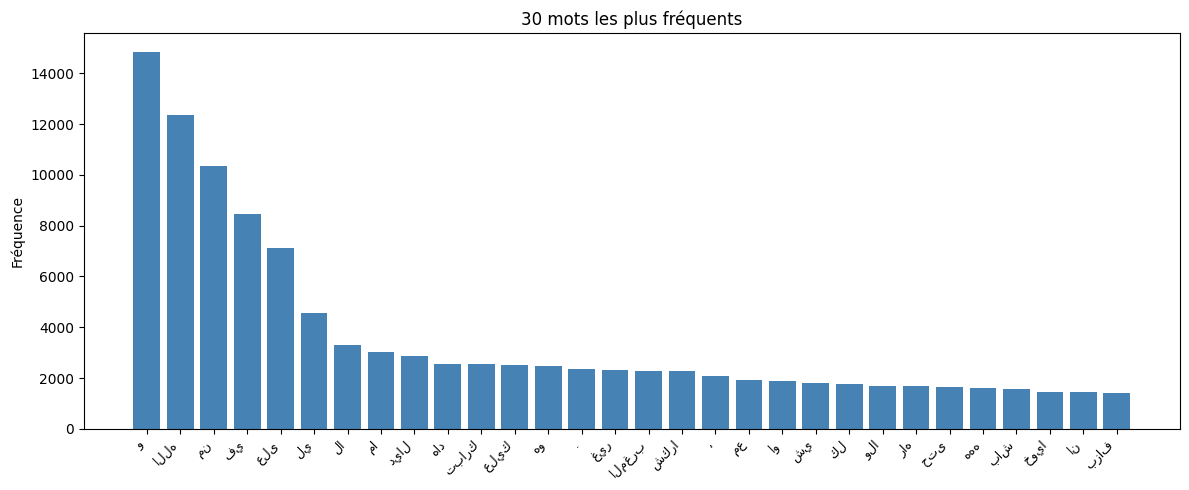


Top 30 mots :
  و                    14847
  الله                 12349
  من                   10355
  في                   8459
  على                  7108
  لي                   4546
  لا                   3309
  ما                   3040
  ديال                 2863
  هاد                  2541
  تبارك                2540
  عليك                 2495
  هو                   2455
  .                    2350
  غير                  2319
  المغرب               2275
  شكرا                 2259
  ،                    2087
  مع                   1918
  او                   1875
  شي                   1818
  كل                   1772
  ولا                  1674
  راه                  1669
  حتى                  1631
  ههه                  1589
  باش                  1585
  خويا                 1456
  ان                   1446
  بزاف                 1425


In [25]:
tous_mots = ' '.join(df_clean['text_clean'].tolist()).split()
freq = Counter(tous_mots).most_common(30)

mots   = [m[0] for m in freq]
counts = [m[1] for m in freq]

plt.figure(figsize=(12,5))
plt.bar(range(len(mots)), counts, color='steelblue')
plt.xticks(range(len(mots)), mots, rotation=45, ha='right', fontsize=9)
plt.title('30 mots les plus fréquents')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

print('\nTop 30 mots :')
for mot, count in freq:
    print(f'  {mot:<20} {count}')

## Cellule 15 — Bigrammes fréquents

In [26]:
def get_bigrams(text):
    words = text.split()
    return [f'{words[i]} {words[i+1]}' for i in range(len(words)-1)]

tous_bigrams = []
for text in df_clean['text_clean']:
    tous_bigrams.extend(get_bigrams(str(text)))

freq_bigrams = Counter(tous_bigrams).most_common(20)

print('Top 20 bigrammes :')
for bigram, count in freq_bigrams:
    print(f'  {bigram:<30} {count}')

Top 20 bigrammes :
  تبارك الله                     2414
  الله عليك                      1554
  الله يعطيك                     647
  يعطيك الصحة                    586
  الله عليكم                     581
  شاء الله                       458
  شكرا على                       418
  الله خيرا                      407
  ماشاء الله                     378
  جزاك الله                      365
  على هاد                        355
  السلام عليكم                   351
  في المغرب                      341
  و لا                           317
  و الله                         300
  سبحان الله                     295
  بارك الله                      291
  الله يرحم                      290
  و لكن                          285
  خدمة نقية                      281


## Cellule 16 — Détection code-switching

Textes avec code-switching : 1514 (3.1%)

Exemples :
['الله يرحم الوالدين قول رأي ديالك على لعاب ديال ميريكان لي كايلعب 9 سميته kampbel', 'Votre valuation et votre analyse de cette guerre et ses tenants et aboutissants sont on ne peut plus pertinentes et hautement professionnelles. الله يكثر من امثالك', 'باغين علاقات الجزائر و المغرب Part 2. كنت قدمت تبرع باش نعاون شويا و لكن مزال ما خرجاتش. اتمنى ان تتم ترجمة المحتوى بالانجليزية لغير الناطقين بالعربية. مهم العالم يتعلم تاريخ المغرب المهم', 'تبارك الله عليك اسي swinga معرفتش كيفاش هد الخدمة كاااملة في أسبوع تقريبا فقط تحية لك', 'سبحان الله الجلبة تدافع عن الصهاyنة والگرافطة تدافع عن ايران', '3عنبة دقيق ملعقة صغيرة خميرة 2 معالق كبار سنيدة ملعقة صغيرة ملحة بيضة خلط جخلط البيض كوبي كاس الحليب وخلطي فنفس الوقت خلطيهم يرتاح 15 min من بعد 15 min خلطيه ب معلقة كبيرة زبدة مقاسحاش دايبة شويا دهنيها بشويا زيت تخمار', 'وليت كنساين r action ديالو كتر من الماتش', 'واش عندك فكرة على تسوية الوضعية المالية ؟ Mustaphaswingaofficiel', 'كتبانلي الجودة ز

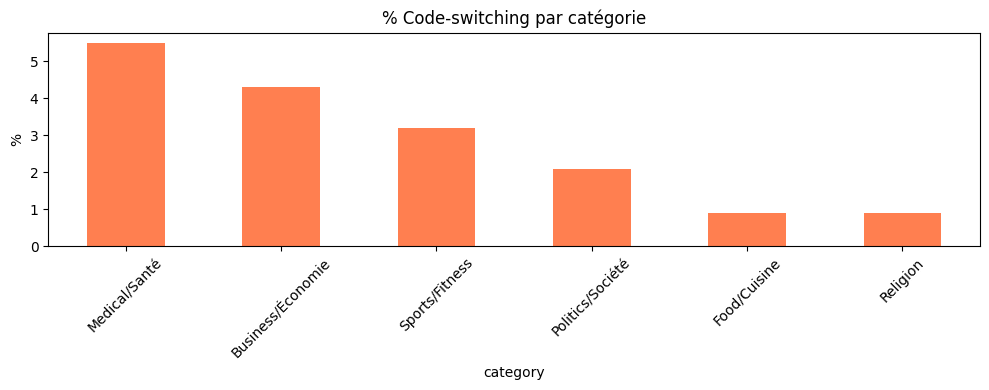

In [27]:
def detect_code_switching(text):
    if not isinstance(text, str):
        return False
    has_arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    has_latin  = bool(re.search(r'[a-zA-Z]', text))
    return has_arabic and has_latin

df_clean['code_switching'] = df_clean['text_clean'].apply(detect_code_switching)

total_cs = df_clean['code_switching'].sum()
pct_cs   = (total_cs / len(df_clean) * 100).round(1)

print(f'Textes avec code-switching : {total_cs} ({pct_cs}%)')
print(f'\nExemples :')
print(df_clean[df_clean['code_switching'] == True]['text_clean'].sample(10).tolist())

cs_cat = df_clean.groupby('category')['code_switching'].mean() * 100
cs_cat = cs_cat.round(1).sort_values(ascending=False)

print(f'\nCode-switching par catégorie :')
print(cs_cat)

cs_cat.plot(kind='bar', figsize=(10,4), color='coral')
plt.title('% Code-switching par catégorie')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cellule 17 — Sauvegarde finale

In [28]:
df_clean = df_clean.drop(columns=['text'], errors='ignore').rename(columns={'text_clean': 'text'})
df_clean.to_csv('../data/processed/all_youtube_comments_clean.csv',
                index=False, encoding='utf-8-sig')

print(f'✅ Fichier sauvegardé : {len(df_clean)} textes propres')
print(f'\nRépartition finale :')
print(df_clean['category'].value_counts())

✅ Fichier sauvegardé : 49310 textes propres

Répartition finale :
category
Politics/Société     14202
Sports/Fitness       10765
Business/Économie    10359
Medical/Santé         6816
Food/Cuisine          3770
Religion              3398
Name: count, dtype: int64
